Loading MNIST...
Accuracy : 0.9878213802435724

Confusion Matrix

[[1348   33]
 [   3 1572]]

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1381
           1       0.98      1.00      0.99      1575

    accuracy                           0.99      2956
   macro avg       0.99      0.99      0.99      2956
weighted avg       0.99      0.99      0.99      2956

Mean of class 0 : [-4.02637823  0.04851153]
Mean of class 1 : [ 3.52740647 -0.04309055]
Distance between class means : 7.554340095428367

Fisher Criterion:
LDA cherche une direction qui maximise la séparation entre les classes
et minimise la dispersion à l'intérieur de chaque classe.

Bayes Rule:
LDA estime la probabilité d'appartenance à chaque classe,
puis choisit la classe la plus probable.



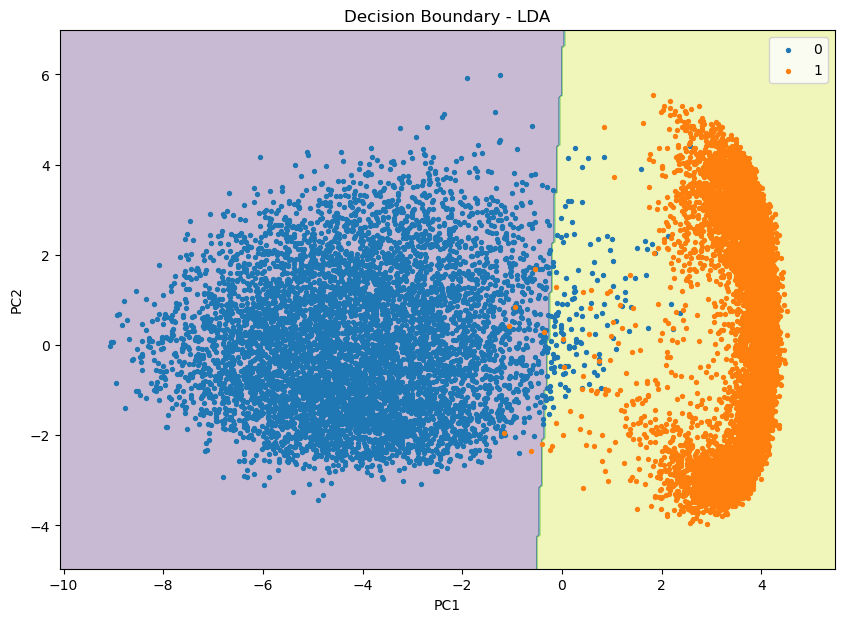

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Loading MNIST...")

mnist = fetch_openml("mnist_784", version=1, as_frame=False)

X = mnist.data
y = mnist.target.astype(int)

mask = (y == 0) | (y == 1)
X = X[mask]
y = y[mask]

X = X / 255.0

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

y_pred = lda.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

mean_0 = np.mean(X_train[y_train == 0], axis=0)
mean_1 = np.mean(X_train[y_train == 1], axis=0)

distance = np.linalg.norm(mean_1 - mean_0)

print("Mean of class 0 :", mean_0)
print("Mean of class 1 :", mean_1)
print("Distance between class means :", distance)

print("""
Fisher Criterion:
LDA cherche une direction qui maximise la séparation entre les classes
et minimise la dispersion à l'intérieur de chaque classe.

Bayes Rule:
LDA estime la probabilité d'appartenance à chaque classe,
puis choisit la classe la plus probable.
""")

h = 0.05

x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

Z = lda.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(
    X_pca[y == 0, 0],
    X_pca[y == 0, 1],
    s=8,
    label="0"
)

plt.scatter(
    X_pca[y == 1, 0],
    X_pca[y == 1, 1],
    s=8,
    label="1"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Decision Boundary - LDA")
plt.legend()
plt.show()